# EX1 — Why PID is needed: an open-loop mouse fails three ways

**What you will see**
1. Two "identical" motors are never identical. With a few % gain mismatch and *no feedback*, the mouse
   hits a wall within a couple of cells.
2. The same open-loop command travels a different distance when the battery is lower.
3. (GIF) The 8 % case animated for the slides.

No controller in this notebook — that is the point.

In [1]:
from mouse_sim import *

cfg = Config()          # <-- edit the numbers in mouse_sim.Config to match your mouse
print(cfg.summary())

counts/rev = 360   counts/mm = 3.58   counts/cell = 645   counts/deg (L-R) = 5.00
passage = 168 mm   clearance per side = 34 mm   battery = 8.4 V / 8.4 V


## 1. Motor mismatch → the mouse veers

Both wheels get the same PWM. The right motor is `(1 - mismatch)` times as strong as the left.

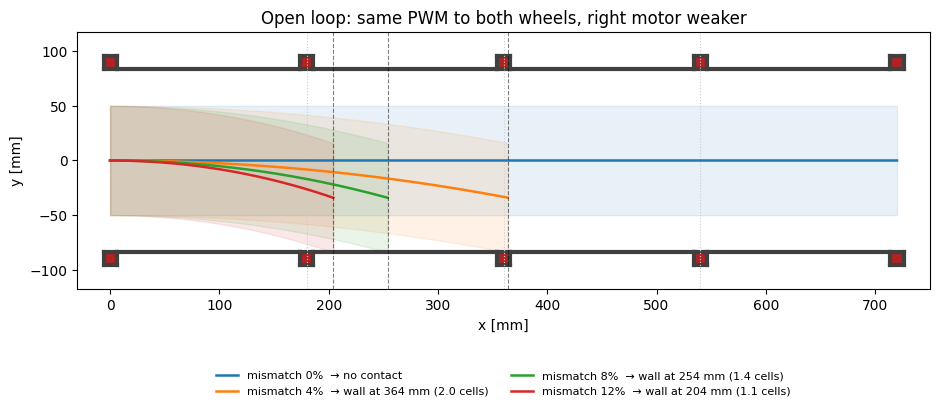

mismatch    0%  ->  no contact in 4 cells
mismatch    4%  ->  body touches wall after 2.02 cells
mismatch    8%  ->  body touches wall after 1.41 cells
mismatch   12%  ->  body touches wall after 1.13 cells


In [2]:
def run_open_loop(cfg, pwm=150, cells=4, t_max=3.0):
    m = DiffDrive(cfg)
    xs, ys, ths = [], [], []
    n = int(t_max / cfg.dt)
    for _ in range(n):
        m.step(pwm, pwm)
        xs.append(m.x); ys.append(m.y); ths.append(m.theta)
        if m.x > cells * cfg.cell:
            break
    return np.array(xs), np.array(ys), np.array(ths)

traces, hits = [], {}
for mm in (0.0, 0.04, 0.08, 0.12):
    xs, ys, ths = run_open_loop(replace(cfg, mismatch=mm))
    hit = wall_contact_x(xs, ys, cfg)
    hits[mm] = hit
    if hit is not None:                      # stop drawing once the body touches the wall
        k = np.searchsorted(xs, hit) + 1
        xs, ys = xs[:k], ys[:k]
    label = f"mismatch {mm*100:.0f}%" + (f"  → wall at {hit*1000:.0f} mm ({hit/cfg.cell:.1f} cells)" if hit else "  → no contact")
    traces.append((label, xs, ys))

fig, ax = plt.subplots(figsize=(11, 3.4))
plot_topview(ax, cfg, traces, cells=4, title="Open loop: same PWM to both wheels, right motor weaker")
for mm, hit in hits.items():
    if hit:
        ax.axvline(hit * 1000, color="k", ls="--", lw=0.8, alpha=0.5)
savefig(fig, "ex01_mismatch_drift.png")
plt.show()

for mm, hit in hits.items():
    print(f"mismatch {mm*100:4.0f}%  ->  " + (f"body touches wall after {hit/cfg.cell:.2f} cells" if hit else "no contact in 4 cells"))

**Talking point:** a 100 mm wide body has only 34 mm of clearance per side (14 mm at the 140 mm rulebook limit).
With an 8 % mismatch the body reaches the wall in about two cells. Nothing in the loop knows it happened.

## 2. Battery voltage → the same command stops at a different place

Command PWM 150 for exactly 1.0 s, then PWM 0, with a full and a partly discharged 2S LiPo.

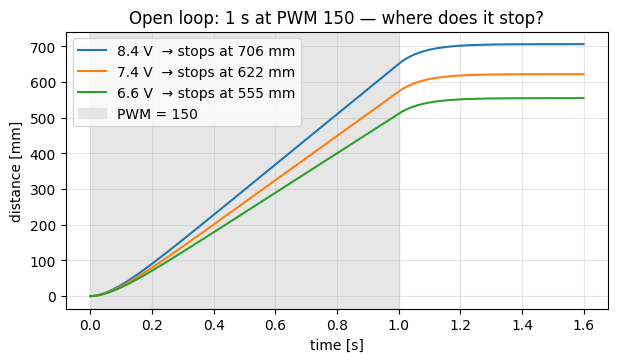

In [3]:
def run_pulse(cfg, pwm=150, t_on=1.0, t_total=1.6):
    m = DiffDrive(cfg)
    t = np.arange(0, t_total, cfg.dt)
    xs = []
    for ti in t:
        m.step(pwm if ti < t_on else 0, pwm if ti < t_on else 0)
        xs.append(m.x)
    return t, np.array(xs)

fig, ax = plt.subplots(figsize=(7, 3.6))
for vb in (8.4, 7.4, 6.6):
    t, xs = run_pulse(replace(cfg, v_batt=vb))
    ax.plot(t, xs * 1000, label=f"{vb:.1f} V  → stops at {xs[-1]*1000:.0f} mm")
ax.axvspan(0, 1.0, color="0.9", label="PWM = 150")
ax.set_xlabel("time [s]"); ax.set_ylabel("distance [mm]")
ax.set_title("Open loop: 1 s at PWM 150 — where does it stop?")
ax.grid(alpha=0.3); ax.legend()
savefig(fig, "ex01_battery_stop.png")
plt.show()

**Talking point:** a 2S LiPo swings from 8.4 V to ~6.6 V during a session → ≈ 20 % less speed for the
same PWM. "Drive for 0.36 s to cross one cell" is not a plan. Measuring distance (encoders) is.

## 3. Animated 8 % case (exported as GIF for the slides)

In [4]:
xs, ys, ths = run_open_loop(replace(cfg, mismatch=0.08), cells=4)
gif = animate_topview(cfg, xs, ys, ths, "figures/ex01_drift_8pct.gif", cells=4,
                      title="Open loop, 8 % motor mismatch — no feedback")
print("saved", gif)

saved figures/ex01_drift_8pct.gif


## Try this
* Set `mismatch=0.02` — how far does it get? (Real motors: 5–15 % spread is normal.)
* Set `mouse_width=0.14` (rulebook maximum). Clearance drops to 14 mm.

## On your mouse
* Put the mouse on the floor, equal PWM to both motors, watch it curve. Note which way → that motor is weaker.
* Read your battery voltage with the ADC — you will need it later for gain scaling (EX6).